In [1]:
!pip install optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 11.8 MB/s eta 0:00:00


In [2]:
import numpy as np
import torch
import optuna
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from copy import deepcopy
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["font.size"] = 11
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

Usando dispositivo: cpu


In [3]:

def f0(x, y):
    """f0(x,y) = x^2 + y^2"""
    return x**2 + y**2

def f1(x, y):
    """Función de Ackley"""
    term1 = -20 * torch.exp(-0.2 * torch.sqrt(0.5 * (x**2 + y**2)))
    term2 = -torch.exp(0.5 * (torch.cos(2 * np.pi * x) + torch.cos(2 * np.pi * y)))
    return term1 + term2 + np.e + 20

def f2(x, y):
    """Función de Himmelblau"""
    return (x**2 + y - 11)**2 + (x + y**2 - 7)**2

FUNCS = {
    "f0 (Cuadrática)": f0,
    "f1 (Ackley)": f1,
    "f2 (Himmelblau)": f2,
}

In [4]:
class PSO:
    """
    Particle Swarm Optimization vectorizado en PyTorch.
    Todos los cálculos se realizan sobre tensores de forma (n_particles, dim).
    """

    def __init__(self, func, n_particles=30, dim=2, bounds=(-10.0, 10.0),
                 w=0.7, c1=1.5, c2=1.5, seed=None):
        self.func = func
        self.n_particles = n_particles
        self.dim = dim
        self.bounds = bounds
        self.w = w
        self.c1 = c1
        self.c2 = c2
        self.device = device
        if seed is not None:
            torch.manual_seed(seed)
            np.random.seed(seed)

    def _init_swarm(self, x0=None):
        lo, hi = self.bounds
        if x0 is None:
            pos = lo + (hi - lo) * torch.rand(self.n_particles, self.dim,
                                              device=self.device)
        else:
            pos = x0.repeat(self.n_particles, 1).clone()
            pos += 0.5 * torch.randn_like(pos)
            pos = torch.clamp(pos, lo, hi)

        vel = torch.zeros_like(pos)
        pbest = pos.clone()
        pbest_val = self._evaluate(pbest)
        idx = torch.argmin(pbest_val)
        gbest = pbest[idx].clone()
        gbest_val = pbest_val[idx].clone()
        return pos, vel, pbest, pbest_val, gbest, gbest_val

    def _evaluate(self, pos):
        x = pos[:, 0]
        y = pos[:, 1]
        return self.func(x, y)

    def optimize(self, max_iter=50, tol=1e-6, x0=None, verbose=False):
        pos, vel, pbest, pbest_val, gbest, gbest_val = self._init_swarm(x0)

        history = {
            "gbest": [gbest.clone()],
            "gbest_val": [gbest_val.item()],
            "particles": [pos.clone()],
            "mean_val": [pbest_val.mean().item()],
        }

        converged = False
        iter_converged = max_iter

        for it in range(max_iter):
            r1 = torch.rand(self.n_particles, self.dim, device=self.device)
            r2 = torch.rand(self.n_particles, self.dim, device=self.device)

            vel = (self.w * vel
                   + self.c1 * r1 * (pbest - pos)
                   + self.c2 * r2 * (gbest.unsqueeze(0) - pos))

            pos = pos + vel
            lo, hi = self.bounds
            pos = torch.clamp(pos, lo, hi)

            vals = self._evaluate(pos)

            improved = vals < pbest_val
            pbest[improved] = pos[improved]
            pbest_val[improved] = vals[improved]

            idx = torch.argmin(pbest_val)
            if pbest_val[idx] < gbest_val:
                gbest = pbest[idx].clone()
                gbest_val = pbest_val[idx].clone()

            history["gbest"].append(gbest.clone())
            history["gbest_val"].append(gbest_val.item())
            history["particles"].append(pos.clone())
            history["mean_val"].append(pbest_val.mean().item())

            if gbest_val.item() < tol and not converged:
                converged = True
                iter_converged = it + 1
                if verbose:
                    print(f"  Convergió en iter {iter_converged} "
                          f"con valor {gbest_val.item():.3e}")

        return history, gbest, gbest_val.item(), converged, iter_converged

In [5]:
pso_test = PSO(f0, n_particles=30, w=0.7, c1=1.5, c2=1.5, seed=SEED)
hist, gbest, gval, conv, itc = pso_test.optimize(max_iter=50, tol=1e-6, verbose=True)
print(f"f0 -> gbest={gbest.numpy()}, valor={gval:.3e}, convergió={conv}, iter={itc}")

  Convergió en iter 47 con valor 6.705e-07
f0 -> gbest=[0.0002641  0.00045859], valor=2.801e-07, convergió=True, iter=47


In [6]:
def make_objective(func_name, func, n_trials_inner=3, max_iter=50):
    def objective(trial):
        n_particles = trial.suggest_int("n_particles", 10, 60, step=5)
        w  = trial.suggest_float("w",  0.1, 0.9)
        c1 = trial.suggest_float("c1", 0.5, 3.0)
        c2 = trial.suggest_float("c2", 0.5, 3.0)

        finals, iters = [], []
        for k in range(n_trials_inner):
            pso = PSO(func, n_particles=n_particles, w=w, c1=c1, c2=c2,
                      seed=SEED + k)
            _, _, gval, conv, itc = pso.optimize(max_iter=max_iter, tol=1e-6)
            finals.append(gval)
            iters.append(itc if conv else max_iter)

        return float(np.mean(finals)) + 1e-3 * float(np.mean(iters))

    return objective


def calibrate_all(max_iter=50, n_trials=25, n_trials_inner=3):
    best_params, studies = {}, {}
    for name, func in FUNCS.items():
        print(f"\n=== Calibrando PSO para {name} ===")
        study = optuna.create_study(direction="minimize",
                                    sampler=optuna.samplers.TPESampler(seed=SEED))
        study.optimize(make_objective(name, func, n_trials_inner, max_iter),
                       n_trials=n_trials, show_progress_bar=True)
        best_params[name] = study.best_params
        studies[name] = study
        print(f"Mejores hiperparámetros para {name}: {study.best_params}")
        print(f"Mejor valor objetivo: {study.best_value:.3e}")
    return best_params, studies


best_params, studies = calibrate_all(max_iter=50, n_trials=25, n_trials_inner=3)


=== Calibrando PSO para f0 (Cuadrática) ===


  0%|          | 0/25 [00:00<?, ?it/s]

Mejores hiperparámetros para f0 (Cuadrática): {'n_particles': 40, 'w': 0.13716033017599819, 'c1': 2.018862129753596, 'c2': 0.9263103092182288}
Mejor valor objetivo: 8.333e-03

=== Calibrando PSO para f1 (Ackley) ===


  0%|          | 0/25 [00:00<?, ?it/s]

Mejores hiperparámetros para f1 (Ackley): {'n_particles': 45, 'w': 0.1199398266984273, 'c1': 2.4708507371263244, 'c2': 1.1656238699226147}
Mejor valor objetivo: 1.767e-02

=== Calibrando PSO para f2 (Himmelblau) ===


  0%|          | 0/25 [00:00<?, ?it/s]

Mejores hiperparámetros para f2 (Himmelblau): {'n_particles': 40, 'w': 0.13716033017599819, 'c1': 2.018862129753596, 'c2': 0.9263103092182288}
Mejor valor objetivo: 1.133e-02


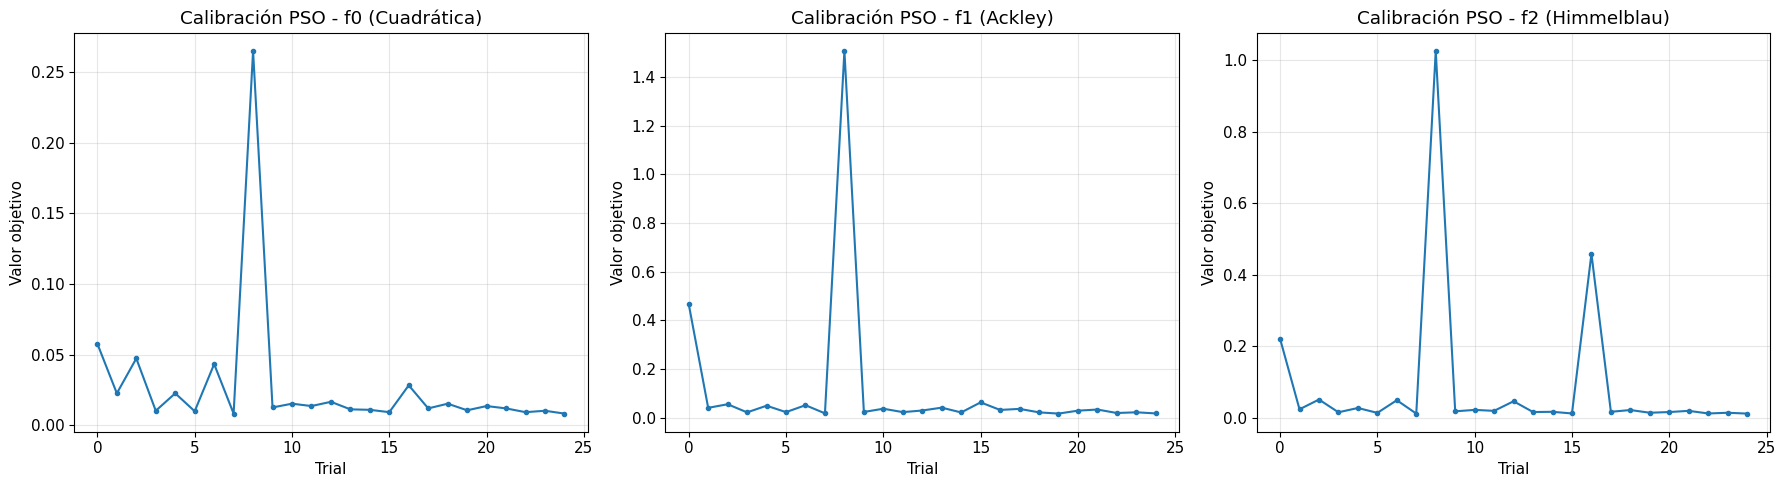

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, study) in zip(axes, studies.items()):
    values = [t.value for t in study.trials if t.value is not None]
    ax.plot(values, marker="o", markersize=3)
    ax.set_title(f"Calibración PSO - {name}")
    ax.set_xlabel("Trial")
    ax.set_ylabel("Valor objetivo")
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
def plot_contour(ax, func, bounds=(-10, 10), n=200, levels=40):
    x = np.linspace(bounds[0], bounds[1], n)
    y = np.linspace(bounds[0], bounds[1], n)
    X, Y = np.meshgrid(x, y)
    Xt = torch.tensor(X, dtype=torch.float32)
    Yt = torch.tensor(Y, dtype=torch.float32)
    Z = func(Xt, Yt).numpy()
    cs = ax.contour(X, Y, Z, levels=levels, cmap="viridis")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    return cs


def plot_pso_trajectory(ax, history, func, title=""):
    plot_contour(ax, func)
    gbest_path = torch.stack(history["gbest"]).numpy()
    ax.plot(gbest_path[:, 0], gbest_path[:, 1], "r.-", linewidth=1.5,
            markersize=5, label="Trayectoria gbest")
    ax.scatter(gbest_path[0, 0], gbest_path[0, 1], c="lime", s=120,
               marker="*", edgecolors="k", label="Inicio")
    ax.scatter(gbest_path[-1, 0], gbest_path[-1, 1], c="red", s=120,
               marker="X", edgecolors="k", label="Final")
    last_particles = history["particles"][-1].numpy()
    ax.scatter(last_particles[:, 0], last_particles[:, 1], c="white",
               s=20, edgecolors="k", alpha=0.7, label="Partículas finales")
    ax.set_title(title)
    ax.legend(loc="best", fontsize=8)

In [9]:
MAX_ITER = 50
N_RUNS = 10
TOL = 1e-6

init_points = torch.tensor(
    [[-8.0, -8.0], [-5.0,  7.0], [ 6.0, -6.0], [ 9.0,  9.0], [-9.0,  2.0],
     [ 3.0, -9.0], [-2.0, -3.0], [ 7.0,  4.0], [-7.0,  5.0], [ 1.0,  1.0]],
    dtype=torch.float32, device=device)

results = {}

for name, func in FUNCS.items():
    params = best_params[name]
    print(f"\n=== Evaluando PSO en {name} con {params} ===")

    rows, histories = [], []
    for run in range(N_RUNS):
        pso = PSO(func, n_particles=params["n_particles"],
                  w=params["w"], c1=params["c1"], c2=params["c2"],
                  seed=SEED + run)
        x0 = init_points[run].unsqueeze(0)
        hist, gbest, gval, conv, itc = pso.optimize(max_iter=MAX_ITER, tol=TOL, x0=x0)
        rows.append({"run": run + 1, "x0": x0.squeeze().tolist(),
                     "gbest": gbest.tolist(), "valor": gval,
                     "convergió": conv, "iter": itc})
        histories.append(hist)

    results[name] = {"rows": rows, "histories": histories, "params": params}

    print(f"{'Run':<4}{'x0':<18}{'gbest':<24}{'Valor':<14}{'Conv':<8}{'Iter':<5}")
    for r in rows:
        print(f"{r['run']:<4}{str(r['x0']):<18}"
              f"{str([round(v,4) for v in r['gbest']]):<24}"
              f"{r['valor']:<14.4e}{str(r['convergió']):<8}{r['iter']:<5}")

    vals = [r["valor"] for r in rows]
    iters = [r["iter"] for r in rows]
    convs = [r["convergió"] for r in rows]
    print(f"\nPromedio valor mínimo: {np.mean(vals):.4e}")
    print(f"Promedio iteraciones:  {np.mean(iters):.2f}")
    print(f"Corridas convergidas:  {sum(convs)}/{N_RUNS}")


=== Evaluando PSO en f0 (Cuadrática) con {'n_particles': 40, 'w': 0.13716033017599819, 'c1': 2.018862129753596, 'c2': 0.9263103092182288} ===
Run x0                gbest                   Valor         Conv    Iter 
1   [-8.0, -8.0]      [-6.8466, -7.0071]      9.5976e+01    False   50   
2   [-5.0, 7.0]       [-3.9981, 5.888]        5.0653e+01    False   50   
3   [6.0, -6.0]       [4.7629, -5.4264]       5.2131e+01    False   50   
4   [9.0, 9.0]        [8.19, 7.7881]          1.2773e+02    False   50   
5   [-9.0, 2.0]       [-7.8626, 1.337]        6.3607e+01    False   50   
6   [3.0, -9.0]       [2.6501, -7.8362]       6.8429e+01    False   50   
7   [-2.0, -3.0]      [-0.8489, -1.663]       3.4863e+00    False   50   
8   [7.0, 4.0]        [6.0633, 2.7872]        4.4532e+01    False   50   
9   [-7.0, 5.0]       [-6.3437, 3.5301]       5.2704e+01    False   50   
10  [1.0, 1.0]        [0.2427, 0.0301]        5.9806e-02    False   50   

Promedio valor mínimo: 5.5931e+01
Promedio


f0 (Cuadrática): mejor corrida = run 10 (iter=50, valor=5.981e-02)


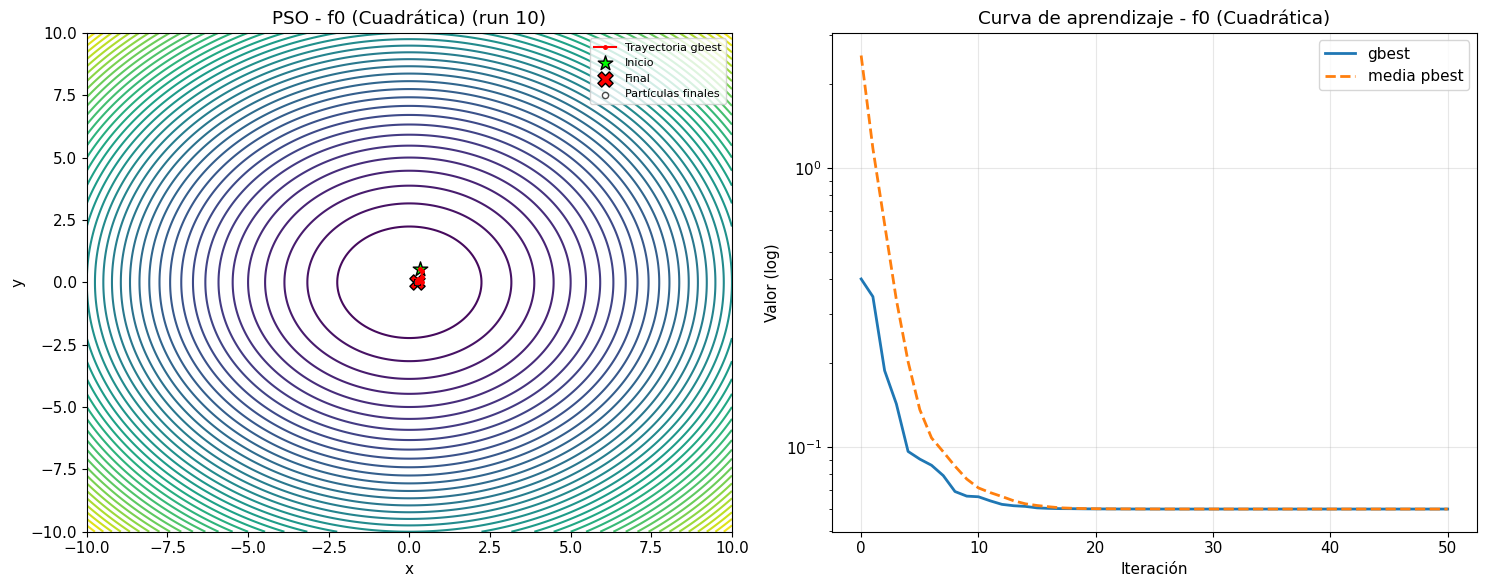


f1 (Ackley): mejor corrida = run 10 (iter=21, valor=0.000e+00)


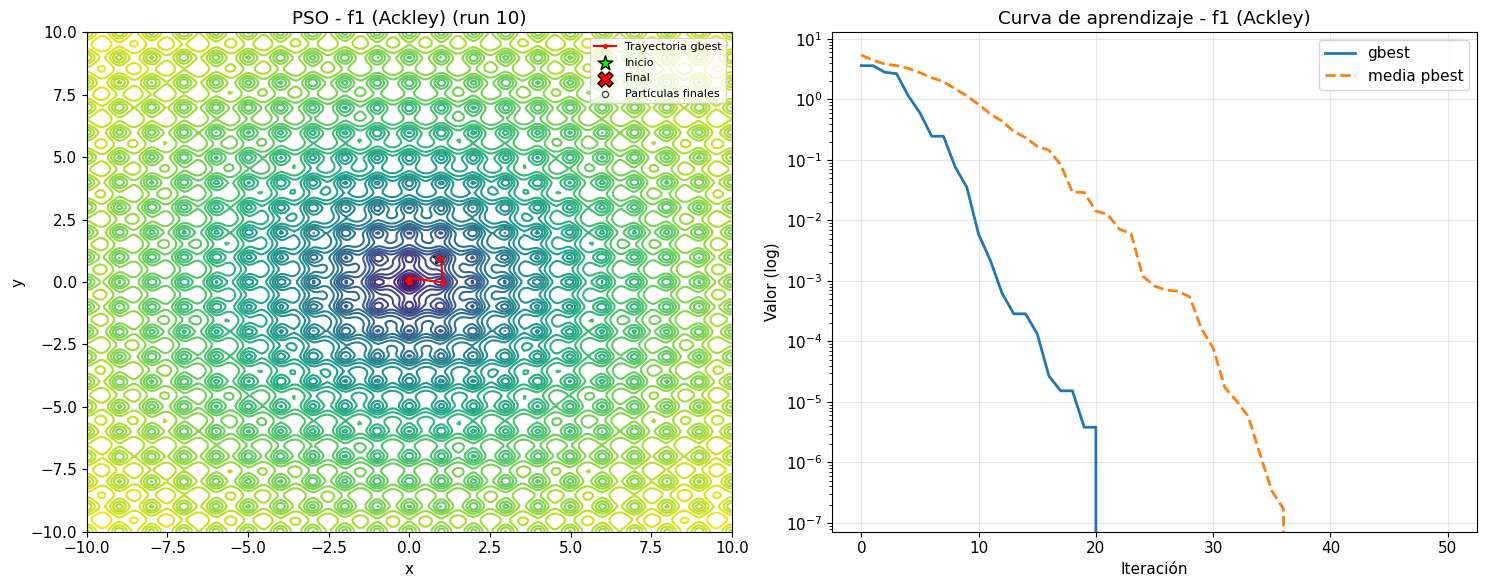


f2 (Himmelblau): mejor corrida = run 7 (iter=50, valor=1.764e+01)


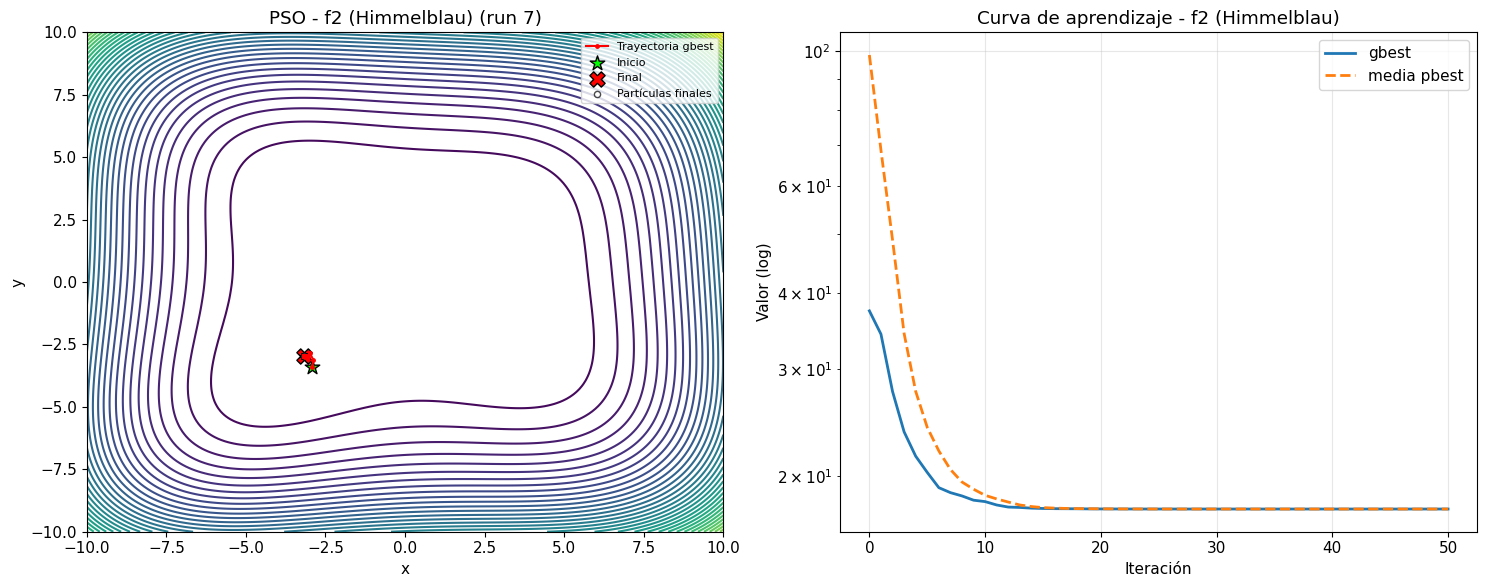

In [10]:
for name, func in FUNCS.items():
    rows = results[name]["rows"]
    histories = results[name]["histories"]

    best_idx = min(range(N_RUNS), key=lambda i: (rows[i]["iter"], rows[i]["valor"]))
    best_hist = histories[best_idx]
    print(f"\n{name}: mejor corrida = run {best_idx+1} "
          f"(iter={rows[best_idx]['iter']}, valor={rows[best_idx]['valor']:.3e})")

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    plot_pso_trajectory(axes[0], best_hist, func,
                        title=f"PSO - {name} (run {best_idx+1})")

    axes[1].plot(best_hist["gbest_val"], label="gbest", linewidth=2)
    axes[1].plot(best_hist["mean_val"], label="media pbest", linewidth=2, linestyle="--")
    axes[1].set_yscale("log")
    axes[1].set_xlabel("Iteración")
    axes[1].set_ylabel("Valor (log)")
    axes[1].set_title(f"Curva de aprendizaje - {name}")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

In [11]:
print("=" * 70)
print("RESUMEN PSO - Promedios sobre 10 corridas")
print("=" * 70)
print(f"{'Función':<22}{'Valor prom':<16}{'Iter prom':<12}{'Converg':<10}")
for name in FUNCS:
    rows = results[name]["rows"]
    vals = [r["valor"] for r in rows]
    iters = [r["iter"] for r in rows]
    convs = sum(r["convergió"] for r in rows)
    print(f"{name:<22}{np.mean(vals):<16.4e}{np.mean(iters):<12.2f}{convs}/10")

RESUMEN PSO - Promedios sobre 10 corridas
Función               Valor prom      Iter prom   Converg   
f0 (Cuadrática)       5.5931e+01      50.00       0/10
f1 (Ackley)           7.2926e+00      47.10       1/10
f2 (Himmelblau)       1.9288e+03      50.00       0/10
